# Chicago Marathon Analysis
Years: 2018, 2019, 2021–2025  (2020 cancelled)

Comparison to Boston — scraping methodology mirrors `scrape_chicago.py`.
Half splits available for 2025 only (different source URL with richer data).

In [10]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd
import seaborn as sns

sns.set_theme(style="whitegrid", palette="muted")
YEARS = [2018, 2019, 2021, 2022, 2023, 2024, 2025]
palette = {"M": "#4C72B0", "F": "#DD8452"}


---
## 1 · Data Loading & Cleaning

In [11]:
def parse_time(s):
    """HH:MM:SS -> seconds, stripping any label prefix (HALF, Finish, etc.)."""
    try:
        s = str(s).strip()
        for prefix in ["HALF", "Finish", "Division", "BIB"]:
            if s.startswith(prefix):
                s = s[len(prefix) :]
        h, m, sec = s.split(":")
        return int(h) * 3600 + int(m) * 60 + int(sec)
    except Exception:
        return np.nan


def fmt_time(secs):
    secs = int(secs)
    return f"{secs // 3600}:{(secs % 3600) // 60:02d}:{secs % 60:02d}"


frames = []
for yr in YEARS:
    try:
        df = pd.read_csv(f"chicago_results_{yr}.csv")
        df["year"] = yr
        frames.append(df)
    except FileNotFoundError:
        print(f"Warning: chicago_results_{yr}.csv not found")

raw = pd.concat(frames, ignore_index=True)
raw = raw.drop_duplicates(subset=["year", "idp"]).reset_index(drop=True)
raw["finish_secs"] = raw["finish_net"].apply(parse_time)
raw = raw.dropna(subset=["finish_secs"])
print(f"Loaded {len(raw):,} rows across {raw['year'].nunique()} years")


Loaded 310,612 rows across 7 years


In [12]:
# Gender inference: within each (year, place_gender) group, faster = Male, slower = Female.
# Edge case: two runners with identical finish times share the same place_gender rank —
# these are same-gender ties (6 male pairs in 2025). We exclude the rank-2 runner in
# ties to avoid miscounting them as Female.

raw["finish_rank_in_pg"] = (
    raw.groupby(["year", "place_gender"])["finish_secs"]
    .rank(method="first")
    .astype(int)
)

# Flag rank-1/rank-2 pairs that have the same finish time (a tie = same gender)
group_min = raw.groupby(["year", "place_gender"])["finish_secs"].transform("min")
group_second = raw.groupby(["year", "place_gender"])["finish_secs"].transform(
    lambda s: s.nsmallest(2).iloc[-1] if len(s) >= 2 else np.nan
)
raw["is_tie"] = raw["finish_rank_in_pg"].isin([1, 2]) & (group_min == group_second)

raw["gender"] = None
raw.loc[raw["finish_rank_in_pg"] == 1, "gender"] = "M"
raw.loc[(raw["finish_rank_in_pg"] == 2) & (~raw["is_tie"]), "gender"] = "F"

df = raw[raw["gender"].notna()].copy()

print("Finishers by year and gender:")
print(df.groupby(["year", "gender"]).size().unstack())


Finishers by year and gender:
gender      F      M
year                
2018    20558  23914
2019    21216  24574
2021    11850  14202
2022    18339  20822
2023    22476  25756
2024    23765  28012
2025    24468  29550


---
## 2 · Negative-Split Rate (2025)

Half splits are only available for 2025 (scraped from `results.chicagomarathon.com/2025/`).

/var/folders/hw/k51wqqw93751fx50t4_d520c0000gn/T/ipykernel_81090/2541023755.py:23: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  by_gender = df25.groupby("gender").apply(


2025 Chicago negative-split rate:
  Overall: 9.3%
  Men:     8.4%
  Women:   10.3%


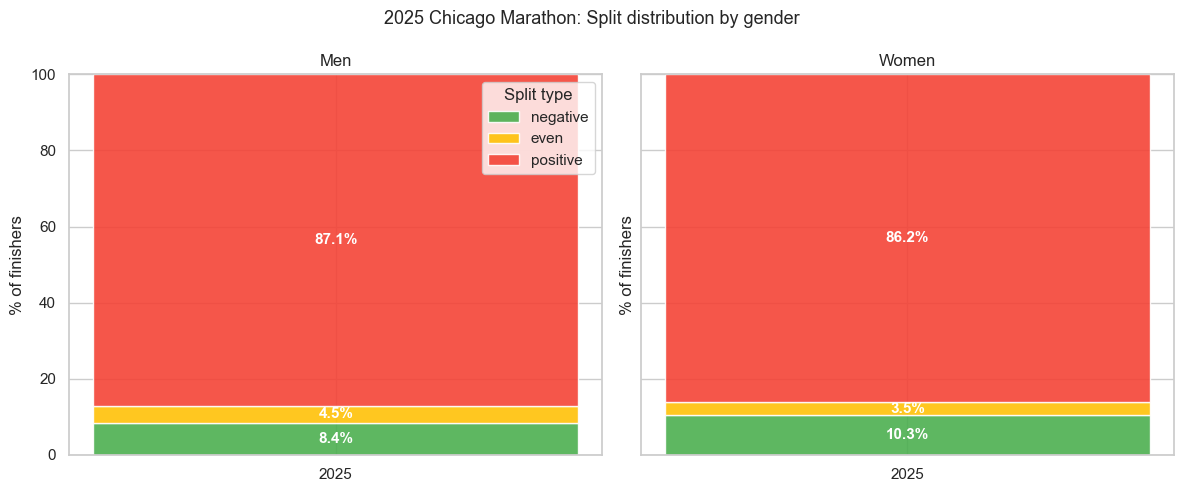

In [20]:
THRESHOLD = 30  # seconds

df25 = df[df["year"] == 2025].copy()
df25["half_secs"] = raw[raw["year"] == 2025]["half"].apply(parse_time)
df25 = df25.dropna(subset=["half_secs"])
df25["second_half"] = df25["finish_secs"] - df25["half_secs"]
df25["split_diff"] = df25["second_half"] - df25["half_secs"]


def classify_split(d):
    if d < -THRESHOLD:
        return "negative"
    elif d > THRESHOLD:
        return "positive"
    else:
        return "even"


df25["split_type"] = df25["split_diff"].apply(classify_split)

# ── Summary stats ────────────────────────────────────────────────────────────
overall_neg = (df25["split_diff"] < -THRESHOLD).mean() * 100
by_gender = df25.groupby("gender").apply(
    lambda g: (g["split_diff"] < -THRESHOLD).mean() * 100
)
print("2025 Chicago negative-split rate:")
print(f"  Overall: {overall_neg:.1f}%")
print(f"  Men:     {by_gender['M']:.1f}%")
print(f"  Women:   {by_gender['F']:.1f}%")

# ── Stacked bar: split distribution by gender ─────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)
split_order = ["negative", "even", "positive"]
split_colors = ["#4CAF50", "#FFC107", "#F44336"]

rates = df25.groupby(["gender", "split_type"]).size().reset_index(name="n")
totals = df25.groupby("gender").size().reset_index(name="total")
rates = rates.merge(totals, on="gender")
rates["pct"] = rates["n"] / rates["total"] * 100

for ax, g in zip(axes, ["M", "F"]):
    sub = (
        rates[rates["gender"] == g]
        .pivot(index="gender", columns="split_type", values="pct")
        .reindex(columns=split_order, fill_value=0)
    )
    bottom = 0
    for col, color in zip(split_order, split_colors):
        val = sub[col].values[0]
        bar = ax.bar(
            ["2025"], [val], bottom=[bottom], color=color, label=col, alpha=0.9
        )
        if val > 2:
            ax.text(
                0,
                bottom + val / 2,
                f"{val:.1f}%",
                ha="center",
                va="center",
                fontsize=11,
                fontweight="bold",
                color="white",
            )
        bottom += val
    ax.set_title(f"{'Men' if g == 'M' else 'Women'}", fontsize=12)
    ax.set_ylabel("% of finishers")
    ax.set_ylim(0, 100)
    if g == "M":
        ax.legend(title="Split type", loc="upper right")

fig.suptitle("2025 Chicago Marathon: Split distribution by gender", fontsize=13)
plt.tight_layout()
plt.show()


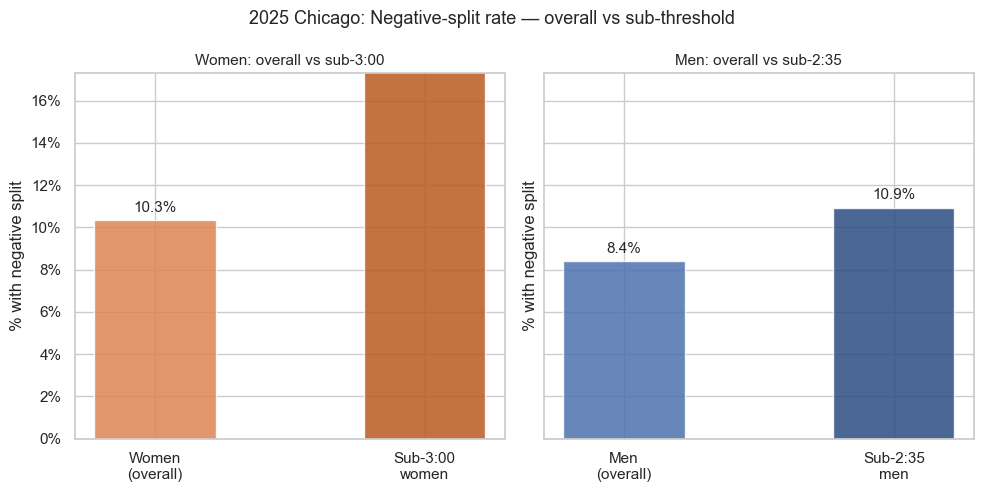

In [ ]:
# Sub-threshold neg-split rate vs overall — 2025 only
# (Half splits only available for 2025)

_SUB3 = 3 * 3600
_SUB235 = 2 * 3600 + 35 * 60

women25 = df25[df25["gender"] == "F"]
men25 = df25[df25["gender"] == "M"]

rates_compare = {
    "Women\n(overall)": (women25["split_diff"] < -THRESHOLD).mean() * 100,
    "Sub-3:00\nwomen": (
        women25[women25["finish_secs"] < _SUB3]["split_diff"] < -THRESHOLD
    ).mean()
    * 100,
    "Men\n(overall)": (men25["split_diff"] < -THRESHOLD).mean() * 100,
    "Sub-2:35\nmen": (
        men25[men25["finish_secs"] < _SUB235]["split_diff"] < -THRESHOLD
    ).mean()
    * 100,
}

palette = {"F": "#DD8452", "M": "#4C72B0"}
bar_colors = [palette["F"], "#b85a1e", palette["M"], "#2a4d80"]

fig, axes = plt.subplots(1, 2, figsize=(10, 5), sharey=True)

for ax, gender, groups, title in [
    (
        axes[0],
        "F",
        ["Women\n(overall)", "Sub-3:00\nwomen"],
        "Women: overall vs sub-3:00",
    ),
    (axes[1], "M", ["Men\n(overall)", "Sub-2:35\nmen"], "Men: overall vs sub-2:35"),
]:
    vals = [rates_compare[g] for g in groups]
    colors = [palette[gender], "#b85a1e" if gender == "F" else "#2a4d80"]
    bars = ax.bar(groups, vals, color=colors, alpha=0.85, width=0.45)
    ax.bar_label(bars, fmt="%.1f%%", padding=4, fontsize=11)
    ax.set_title(title, fontsize=11)
    ax.set_ylabel("% with negative split")
    ax.set_ylim(0, max(vals) * 1.4 + 2)
    ax.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.0f%%"))

fig.suptitle(
    "2025 Chicago: Negative-split rate — overall vs sub-threshold", fontsize=13
)
plt.tight_layout()
plt.show()


---
## 3 · Sub-3 Women & Men's Equivalent

In [ ]:
SUB3 = 3 * 3600
SUB235 = 2 * 3600 + 35 * 60

results = []
for yr in YEARS:
    sub = df[df["year"] == yr]
    women = sub[sub["gender"] == "F"].sort_values("finish_secs")
    men = sub[sub["gender"] == "M"].sort_values("finish_secs")
    sub3w = women[women["finish_secs"] < SUB3]
    n = len(sub3w)
    equiv = men.iloc[n - 1]["finish_secs"] if n > 0 and n <= len(men) else np.nan
    n_sub235_men = len(men[men["finish_secs"] < SUB235])
    results.append(
        {
            "year": yr,
            "n_sub3_women": n,
            "n_sub235_men": n_sub235_men,
            "mens_equiv_secs": equiv,
        }
    )

sub3_df = pd.DataFrame(results)
sub3_df["mens_equiv_fmt"] = sub3_df["mens_equiv_secs"].apply(
    lambda s: fmt_time(s) if pd.notna(s) else ""
)
print(sub3_df[["year", "n_sub3_women", "n_sub235_men", "mens_equiv_fmt"]])


   year  n_sub3_women  n_sub235_men mens_equiv_fmt
0  2018           120           135        2:34:14
1  2019           206           192        2:36:02
2  2021            88            76        2:36:47
3  2022           176           203        2:33:26
4  2023           317           281        2:36:02
5  2024           236           230        2:35:10
6  2025           393           352        2:35:46


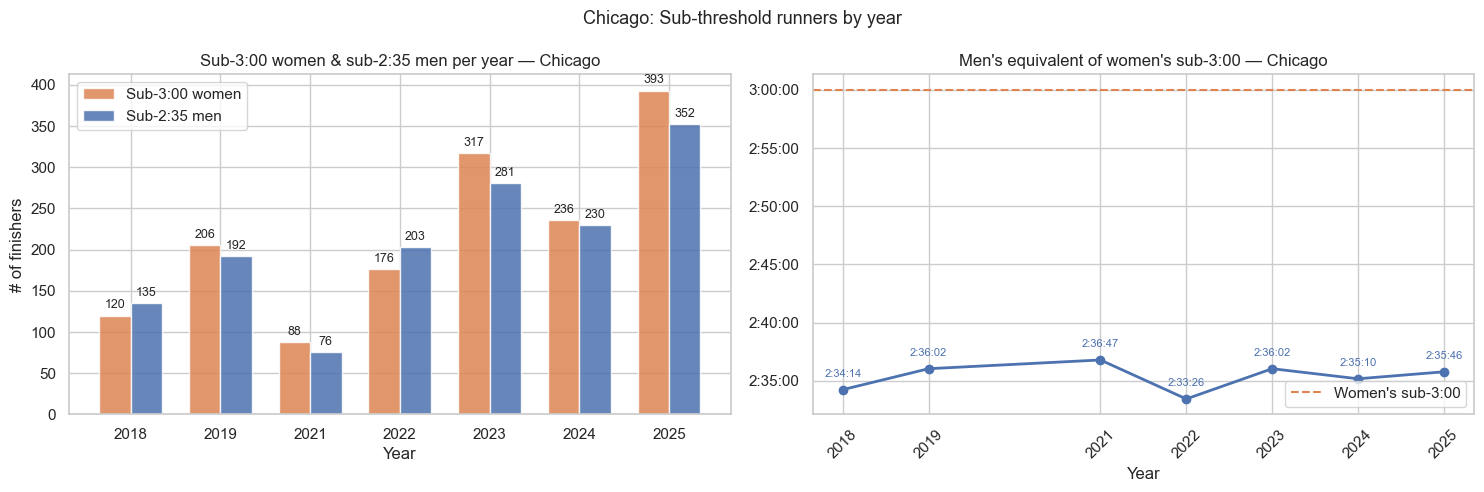

In [ ]:
x = np.arange(len(sub3_df))
width = 0.35

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# ── Left: sub-3 women vs sub-2:35 men side-by-side ───────────────────────────
ax = axes[0]
bars_f = ax.bar(
    x - width / 2,
    sub3_df["n_sub3_women"],
    width,
    color=palette["F"],
    alpha=0.85,
    label="Sub-3:00 women",
)
bars_m = ax.bar(
    x + width / 2,
    sub3_df["n_sub235_men"],
    width,
    color=palette["M"],
    alpha=0.85,
    label="Sub-2:35 men",
)
ax.bar_label(bars_f, padding=3, fontsize=9)
ax.bar_label(bars_m, padding=3, fontsize=9)
ax.set_title("Sub-3:00 women & sub-2:35 men per year — Chicago", fontsize=12)
ax.set_xlabel("Year")
ax.set_ylabel("# of finishers")
ax.set_xticks(x)
ax.set_xticklabels(sub3_df["year"])
ax.legend()

# ── Right: men's equivalent time ─────────────────────────────────────────────
ax = axes[1]
ax.plot(
    sub3_df["year"],
    sub3_df["mens_equiv_secs"] / 60,
    marker="o",
    color=palette["M"],
    linewidth=2,
)
for _, row in sub3_df.iterrows():
    ax.annotate(
        row["mens_equiv_fmt"],
        (row["year"], row["mens_equiv_secs"] / 60),
        textcoords="offset points",
        xytext=(0, 9),
        ha="center",
        fontsize=8,
        color=palette["M"],
    )
ax.axhline(
    SUB3 / 60,
    color=palette["F"],
    linestyle="--",
    linewidth=1.5,
    label="Women's sub-3:00",
)
ax.set_title("Men's equivalent of women's sub-3:00 — Chicago", fontsize=12)
ax.set_xlabel("Year")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: fmt_time(x * 60)))
ax.set_xticks(sub3_df["year"])
ax.tick_params(axis="x", rotation=45)
ax.legend()

fig.suptitle("Chicago: Sub-threshold runners by year", fontsize=13)
plt.tight_layout()
plt.show()


---
## 4 · Median Finish Time: Chicago vs. Boston

In [17]:
# Load Boston data (CSV files are in the same directory)
BOS_YEARS = [2018, 2019, 2021, 2022, 2023, 2024, 2025, 2026]

bos_frames = []
for yr in BOS_YEARS:
    try:
        bf = pd.read_csv(f"results_{yr}.csv")
        bf["year"] = yr
        bos_frames.append(bf)
    except FileNotFoundError:
        pass

bos_raw = pd.concat(bos_frames, ignore_index=True)
bos_raw = bos_raw.drop_duplicates(subset=["year", "idp"]).reset_index(drop=True)
bos_raw["finish_secs"] = bos_raw["finish_net"].apply(parse_time)
bos_raw = bos_raw.dropna(subset=["finish_secs"])
bos_raw["finish_rank_in_pg"] = (
    bos_raw.groupby(["year", "place_gender"])["finish_secs"]
    .rank(method="first")
    .astype(int)
)
bos_raw["gender"] = bos_raw["finish_rank_in_pg"].map({1: "M", 2: "F"})
bos_df = bos_raw[bos_raw["gender"].notna()].copy()
print(f"Boston: {len(bos_df):,} rows loaded")


Boston: 197,755 rows loaded


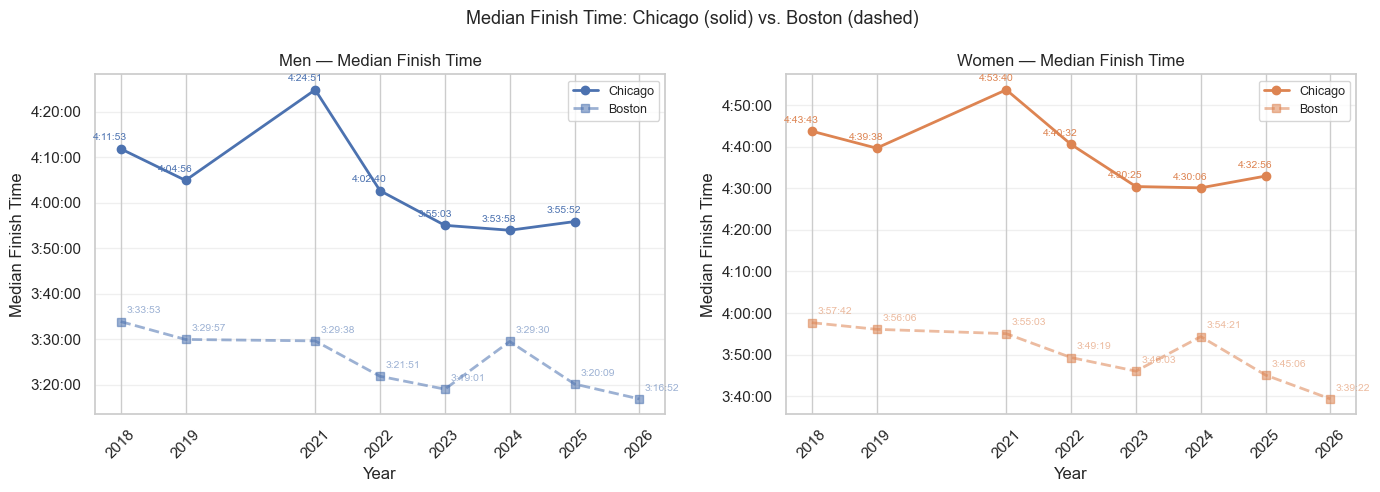

Chicago median times:
gender        F        M
year                    
2018    4:43:43  4:11:53
2019    4:39:38  4:04:56
2021    4:53:40  4:24:51
2022    4:40:32  4:02:40
2023    4:30:25  3:55:03
2024    4:30:06  3:53:58
2025    4:32:56  3:55:52

Boston median times (shared years):
gender        F        M
year                    
2018    3:57:42  3:33:53
2019    3:56:06  3:29:57
2021    3:55:03  3:29:38
2022    3:49:19  3:21:51
2023    3:46:03  3:19:01
2024    3:54:21  3:29:30
2025    3:45:06  3:20:09


In [18]:
chi_med = (
    df.groupby(["year", "gender"])["finish_secs"]
    .median()
    .reset_index(name="median_secs")
)
bos_med = (
    bos_df.groupby(["year", "gender"])["finish_secs"]
    .median()
    .reset_index(name="median_secs")
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=False)

for ax, gender, title in [
    (axes[0], "M", "Men"),
    (axes[1], "F", "Women"),
]:
    chi_g = chi_med[chi_med["gender"] == gender].sort_values("year")
    bos_g = bos_med[bos_med["gender"] == gender].sort_values("year")

    ax.plot(
        chi_g["year"],
        chi_g["median_secs"] / 60,
        marker="o",
        color=palette[gender],
        linewidth=2,
        label="Chicago",
    )
    for _, row in chi_g.iterrows():
        ax.annotate(
            fmt_time(row["median_secs"]),
            (row["year"], row["median_secs"] / 60),
            textcoords="offset points",
            xytext=(-20, 6),
            fontsize=7.5,
            color=palette[gender],
        )

    ax.plot(
        bos_g["year"],
        bos_g["median_secs"] / 60,
        marker="s",
        color=palette[gender],
        linewidth=2,
        linestyle="--",
        alpha=0.55,
        label="Boston",
    )
    for _, row in bos_g.iterrows():
        ax.annotate(
            fmt_time(row["median_secs"]),
            (row["year"], row["median_secs"] / 60),
            textcoords="offset points",
            xytext=(4, 6),
            fontsize=7.5,
            color=palette[gender],
            alpha=0.55,
        )

    ax.set_title(f"{title} — Median Finish Time", fontsize=12)
    ax.set_xlabel("Year")
    ax.set_ylabel("Median Finish Time")
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: fmt_time(x * 60)))
    ax.set_xticks(sorted(set(chi_g["year"].tolist() + bos_g["year"].tolist())))
    ax.tick_params(axis="x", rotation=45)
    ax.legend(fontsize=9)
    ax.grid(axis="y", alpha=0.3)

fig.suptitle("Median Finish Time: Chicago (solid) vs. Boston (dashed)", fontsize=13)
plt.tight_layout()
plt.show()

print("Chicago median times:")
print(chi_med.pivot(index="year", columns="gender", values="median_secs").map(fmt_time))
print()
print("Boston median times (shared years):")
shared = bos_med[bos_med["year"].isin(YEARS)]
print(shared.pivot(index="year", columns="gender", values="median_secs").map(fmt_time))


---
## 5 · Sub-3 Women: Chicago vs. Boston

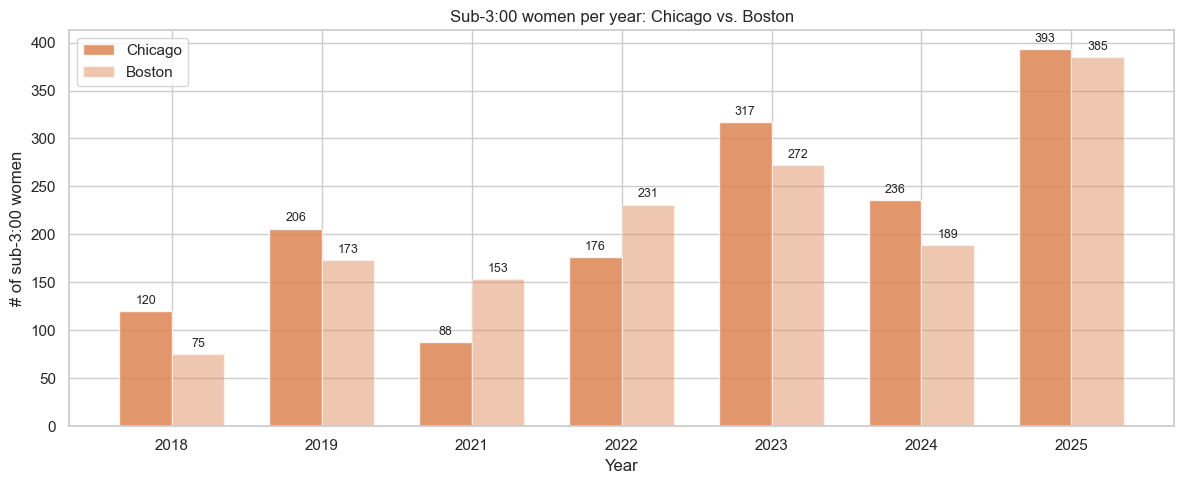

In [19]:
bos_sub3 = []
for yr in BOS_YEARS:
    sub = bos_df[bos_df["year"] == yr]
    women = sub[sub["gender"] == "F"]
    n = len(women[women["finish_secs"] < SUB3])
    bos_sub3.append({"year": yr, "n": n})
bos_sub3_df = pd.DataFrame(bos_sub3)

# Side-by-side grouped bars for shared years
shared_years = sorted(set(YEARS) & set(BOS_YEARS))
chi_counts = [
    sub3_df[sub3_df["year"] == yr]["n_sub3_women"].iloc[0]
    if yr in sub3_df["year"].values
    else 0
    for yr in shared_years
]
bos_counts = [
    bos_sub3_df[bos_sub3_df["year"] == yr]["n"].iloc[0]
    if yr in bos_sub3_df["year"].values
    else 0
    for yr in shared_years
]

x = np.arange(len(shared_years))
width = 0.35
fig, ax = plt.subplots(figsize=(12, 5))

b1 = ax.bar(
    x - width / 2, chi_counts, width, color=palette["F"], alpha=0.85, label="Chicago"
)
b2 = ax.bar(
    x + width / 2, bos_counts, width, color=palette["F"], alpha=0.45, label="Boston"
)
ax.bar_label(b1, padding=3, fontsize=9)
ax.bar_label(b2, padding=3, fontsize=9)

ax.set_xlabel("Year")
ax.set_ylabel("# of sub-3:00 women")
ax.set_title("Sub-3:00 women per year: Chicago vs. Boston")
ax.set_xticks(x)
ax.set_xticklabels(shared_years)
ax.legend()
plt.tight_layout()
plt.show()
